# Project: HOUSE PRICE PREDICTION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [ ]:

df = pd.read_csv("/content/house_data.csv")

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Extract useful information from date
df['sale_year'] = df['date'].dt.year
df['sale_month'] = df['date'].dt.month

# House age at the time of sale
df['age'] = df['sale_year'] - df['yr_built']

# Whether the house was renovated
df['renovated'] = (df['yr_renovated'] > 0).astype(int)

# Years since renovation
df['years_since_renovation'] = np.where(
    df['yr_renovated'] > 0,
    df['sale_year'] - df['yr_renovated'],
    df['age']
)

# Remove only the identifier
df.drop(columns=['id', 'date'], inplace=True)

df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,age,renovated,years_since_renovation
0,221900,3,1.00,1180,5650,1.0,0,0,3,7,...,98178,47.5112,-122.257,1340,5650,2014,10,59,0,59
1,538000,3,2.25,2570,7242,2.0,0,0,3,7,...,98125,47.7210,-122.319,1690,7639,2014,12,63,1,23
2,180000,2,1.00,770,10000,1.0,0,0,3,6,...,98028,47.7379,-122.233,2720,8062,2015,2,82,0,82
3,604000,4,3.00,1960,5000,1.0,0,0,5,7,...,98136,47.5208,-122.393,1360,5000,2014,12,49,0,49
4,510000,3,2.00,1680,8080,1.0,0,0,3,8,...,98074,47.6168,-122.045,1800,7503,2015,2,28,0,28


In [ ]:
# Total usable living space
df['total_sqft'] = df['sqft_living'] + df['sqft_basement']

# Total bathrooms-related interaction
df['sqft_per_bedroom'] = df['sqft_living'] / (df['bedrooms'] + 1)

# Living area compared with lot size
df['living_lot_ratio'] = df['sqft_living'] / (df['sqft_lot'] + 1)

# Above-ground living area proportion
df['above_ratio'] = df['sqft_above'] / (df['sqft_living'] + 1)

# Basement indicator
df['has_basement'] = (df['sqft_basement'] > 0).astype(int)

# Renovation indicator already created
df['has_waterfront'] = df['waterfront']

df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sale_month,age,renovated,years_since_renovation,total_sqft,sqft_per_bedroom,living_lot_ratio,above_ratio,has_basement,has_waterfront
0,221900,3,1.00,1180,5650,1.0,0,0,3,7,...,10,59,0,59,1180,295.000000,0.208813,0.999153,0,0
1,538000,3,2.25,2570,7242,2.0,0,0,3,7,...,12,63,1,23,2970,642.500000,0.354825,0.844030,1,0
2,180000,2,1.00,770,10000,1.0,0,0,3,6,...,2,82,0,82,770,256.666667,0.076992,0.998703,0,0
3,604000,4,3.00,1960,5000,1.0,0,0,5,7,...,12,49,0,49,2870,392.000000,0.391922,0.535441,1,0
4,510000,3,2.00,1680,8080,1.0,0,0,3,8,...,2,28,0,28,1680,420.000000,0.207895,0.999405,0,0


In [ ]:
df.shape

(21613, 30)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   21613 non-null  int64  
 1   bedrooms                21613 non-null  int64  
 2   bathrooms               21613 non-null  float64
 3   sqft_living             21613 non-null  int64  
 4   sqft_lot                21613 non-null  int64  
 5   floors                  21613 non-null  float64
 6   waterfront              21613 non-null  int64  
 7   view                    21613 non-null  int64  
 8   condition               21613 non-null  int64  
 9   grade                   21613 non-null  int64  
 10  sqft_above              21613 non-null  int64  
 11  sqft_basement           21613 non-null  int64  
 12  yr_built                21613 non-null  int64  
 13  yr_renovated            21613 non-null  int64  
 14  zipcode                 21613 non-null

In [ ]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sale_month,age,renovated,years_since_renovation,total_sqft,sqft_per_bedroom,living_lot_ratio,above_ratio,has_basement,has_waterfront
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,...,6.574423,43.317818,0.042289,40.936936,2371.408782,470.591610,0.323645,0.874982,0.392680,0.007542
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,...,3.115308,29.375493,0.201253,28.813643,1180.287267,170.393494,0.268354,0.170820,0.488358,0.086517
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,-1.000000,0.000000,-1.000000,290.000000,47.647059,0.000610,0.333142,0.000000,0.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,...,4.000000,18.000000,0.000000,15.000000,1500.000000,355.000000,0.156566,0.725720,0.000000,0.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,...,6.000000,40.000000,0.000000,37.000000,2170.000000,438.000000,0.247625,0.999131,0.000000,0.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,...,9.000000,63.000000,0.000000,60.000000,2990.000000,550.333333,0.407459,0.999490,1.000000,0.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,...,12.000000,115.000000,1.000000,115.000000,17670.000000,4810.000000,4.644914,0.999875,1.000000,1.000000


In [ ]:
df.isnull().sum()

,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0
grade,0


In [ ]:
df.nunique()

,0
price,4032
bedrooms,13
bathrooms,30
sqft_living,1038
sqft_lot,9782
floors,6
waterfront,2
view,5
condition,5
grade,12


## EDA


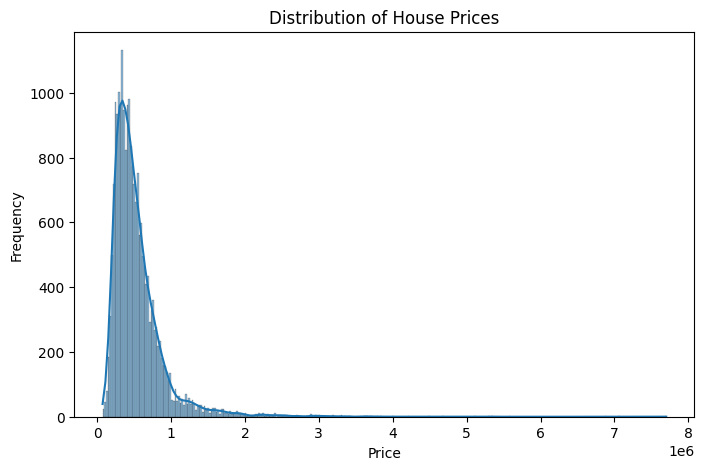

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Text(0.5, 1.0, 'Distribution of Price after Tranformation')

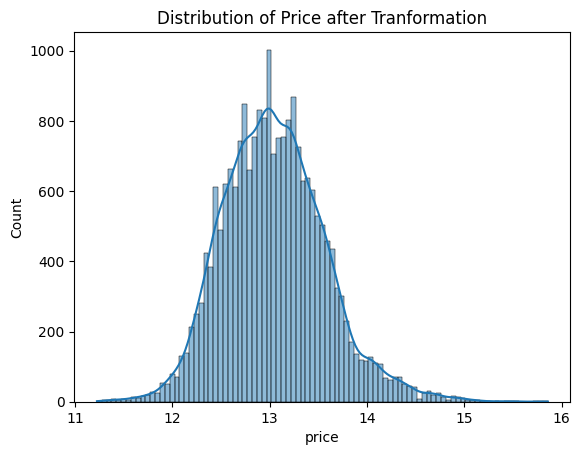

In [ ]:
sns.histplot(np.log1p(df['price']),kde=True).set_title("Distribution of Price after Tranformation")


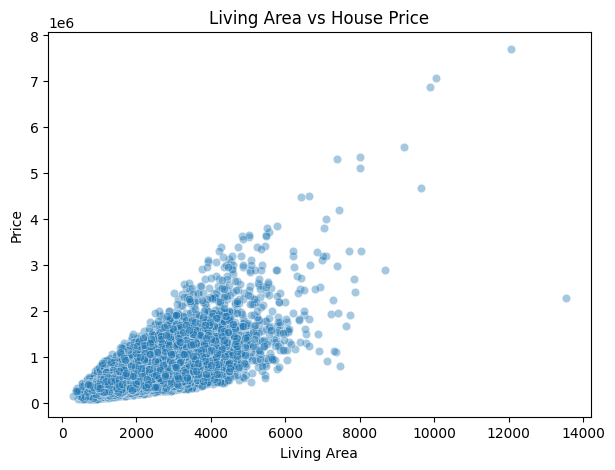

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.4)
plt.title('Living Area vs House Price')
plt.xlabel('Living Area')
plt.ylabel('Price')
plt.show()

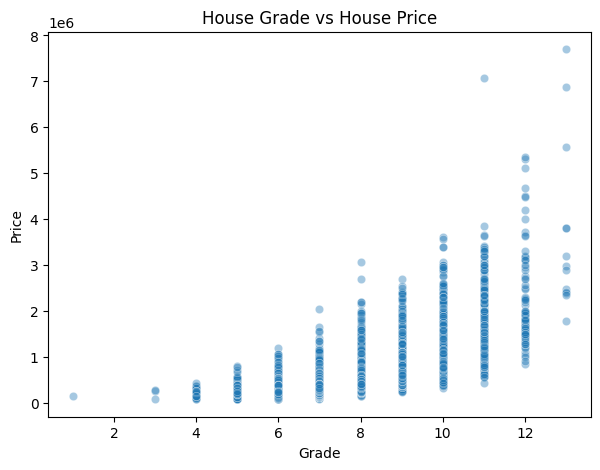

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='grade', y='price', alpha=0.4)
plt.title('House Grade vs House Price')
plt.xlabel('Grade')
plt.ylabel('Price')
plt.show()

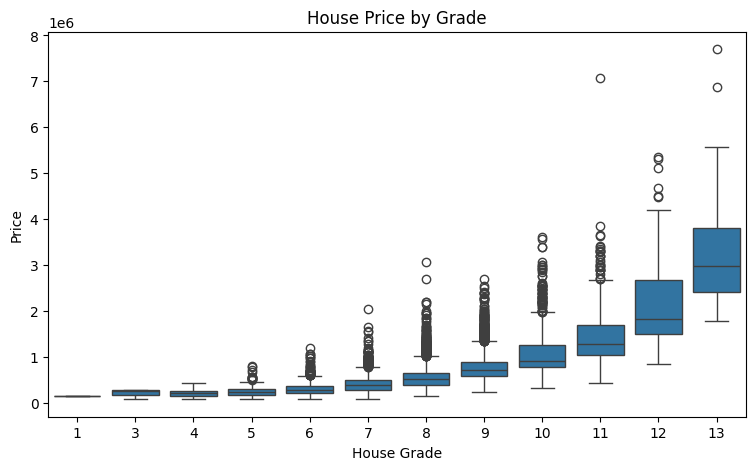

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='grade',
    y='price'
)

plt.title('House Price by Grade')
plt.xlabel('House Grade')
plt.ylabel('Price')
plt.show()

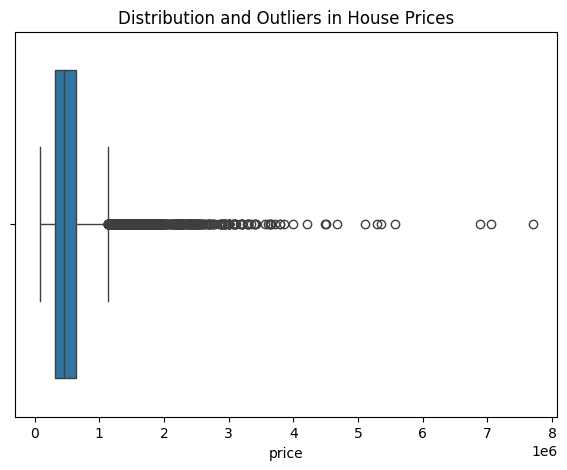

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df['price'])
plt.title('Distribution and Outliers in House Prices')
plt.show()

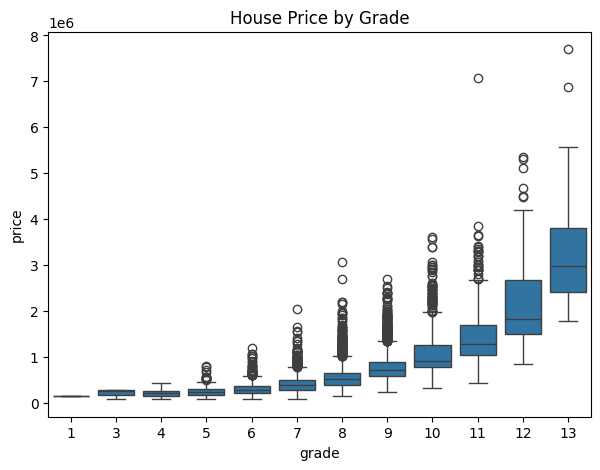

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df['grade'], y=df['price'])
plt.title('House Price by Grade')
plt.show()

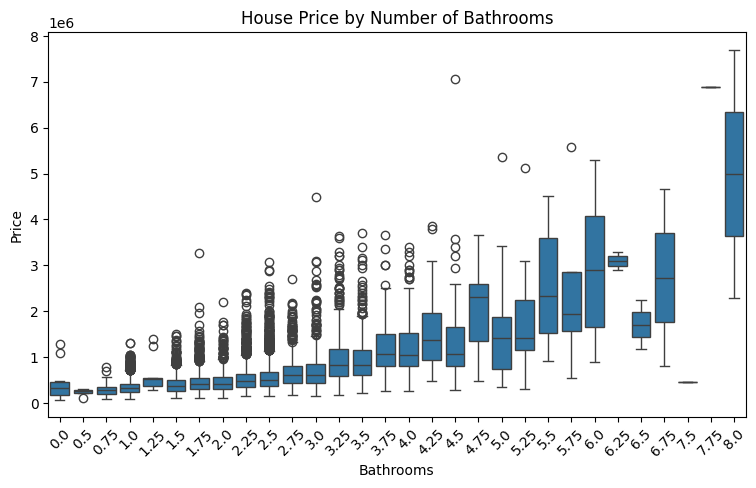

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='bathrooms',
    y='price'
)

plt.title('House Price by Number of Bathrooms')
plt.xlabel('Bathrooms')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

In [ ]:
corr_matrix = df.corr(numeric_only=True)

In [ ]:
print(corr_matrix)

                           price  bedrooms  bathrooms  sqft_living  sqft_lot  \
price                   1.000000  0.308350   0.525138     0.702035  0.089661   
bedrooms                0.308350  1.000000   0.515884     0.576671  0.031703   
bathrooms               0.525138  0.515884   1.000000     0.754665  0.087740   
sqft_living             0.702035  0.576671   0.754665     1.000000  0.172826   
sqft_lot                0.089661  0.031703   0.087740     0.172826  1.000000   
floors                  0.256794  0.175429   0.500653     0.353949 -0.005201   
waterfront              0.266369 -0.006582   0.063744     0.103818  0.021604   
view                    0.397293  0.079532   0.187737     0.284611  0.074710   
condition               0.036362  0.028472  -0.124982    -0.058753 -0.008958   
grade                   0.667434  0.356967   0.664983     0.762704  0.113621   
sqft_above              0.605567  0.477600   0.685342     0.876597  0.183512   
sqft_basement           0.323816  0.3030

In [ ]:
df[['sqft_living',
    'sqft_basement',
    'total_sqft']].corr()

,sqft_living,sqft_basement,total_sqft
sqft_living,1.000000,0.435043,0.941279
sqft_basement,0.435043,1.000000,0.713501
total_sqft,0.941279,0.713501,1.000000


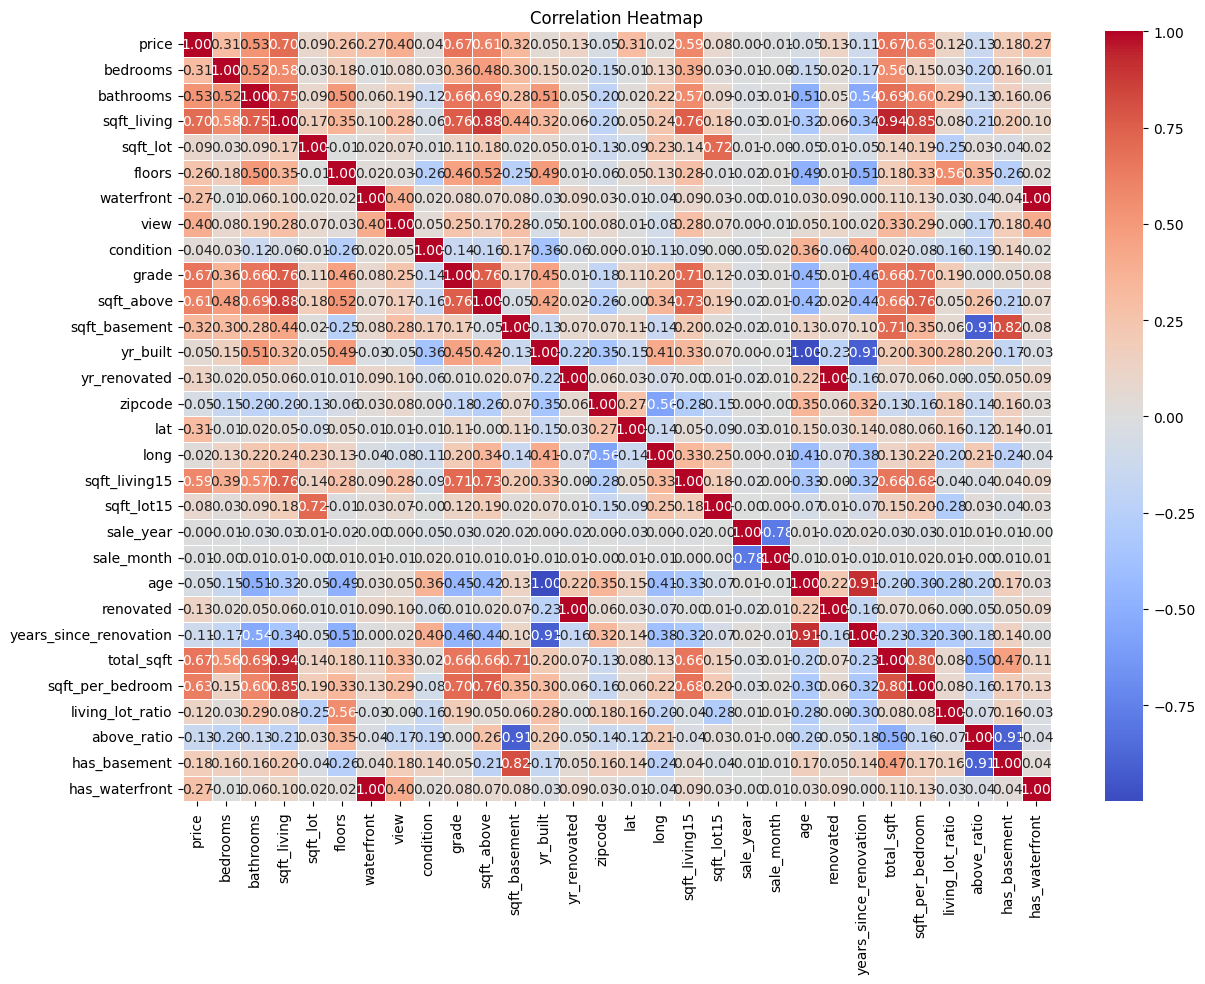

In [ ]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

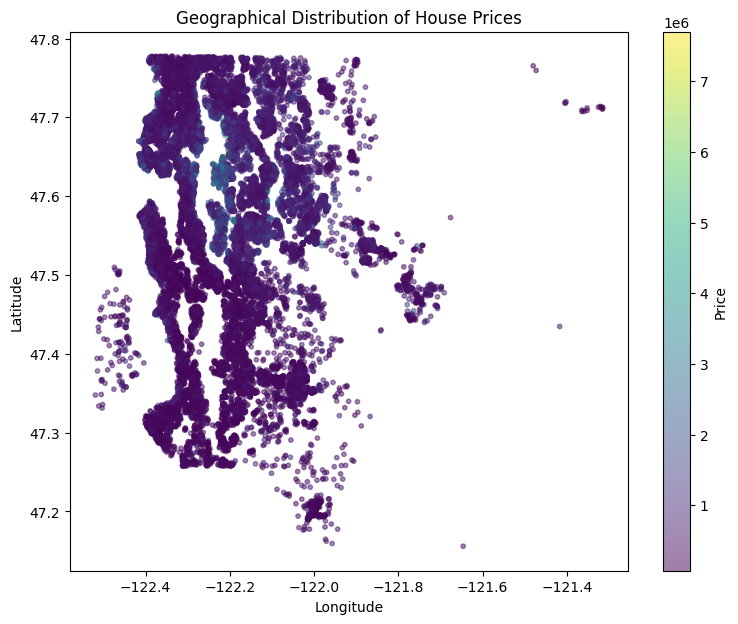

In [ ]:
plt.figure(figsize=(9,7))

scatter = plt.scatter(
    df['long'],
    df['lat'],
    c=df['price'],
    s=10,
    alpha=0.5
)

plt.colorbar(scatter, label='Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of House Prices')
plt.show()

In [ ]:
# df.corr()['price'].sort_values(ascending=False)

##
Visualizing the coorelation with price

In [ ]:

#df.corr()['price'][:-1].sort_values().plot(kind='bar')

## Visulaizing the data

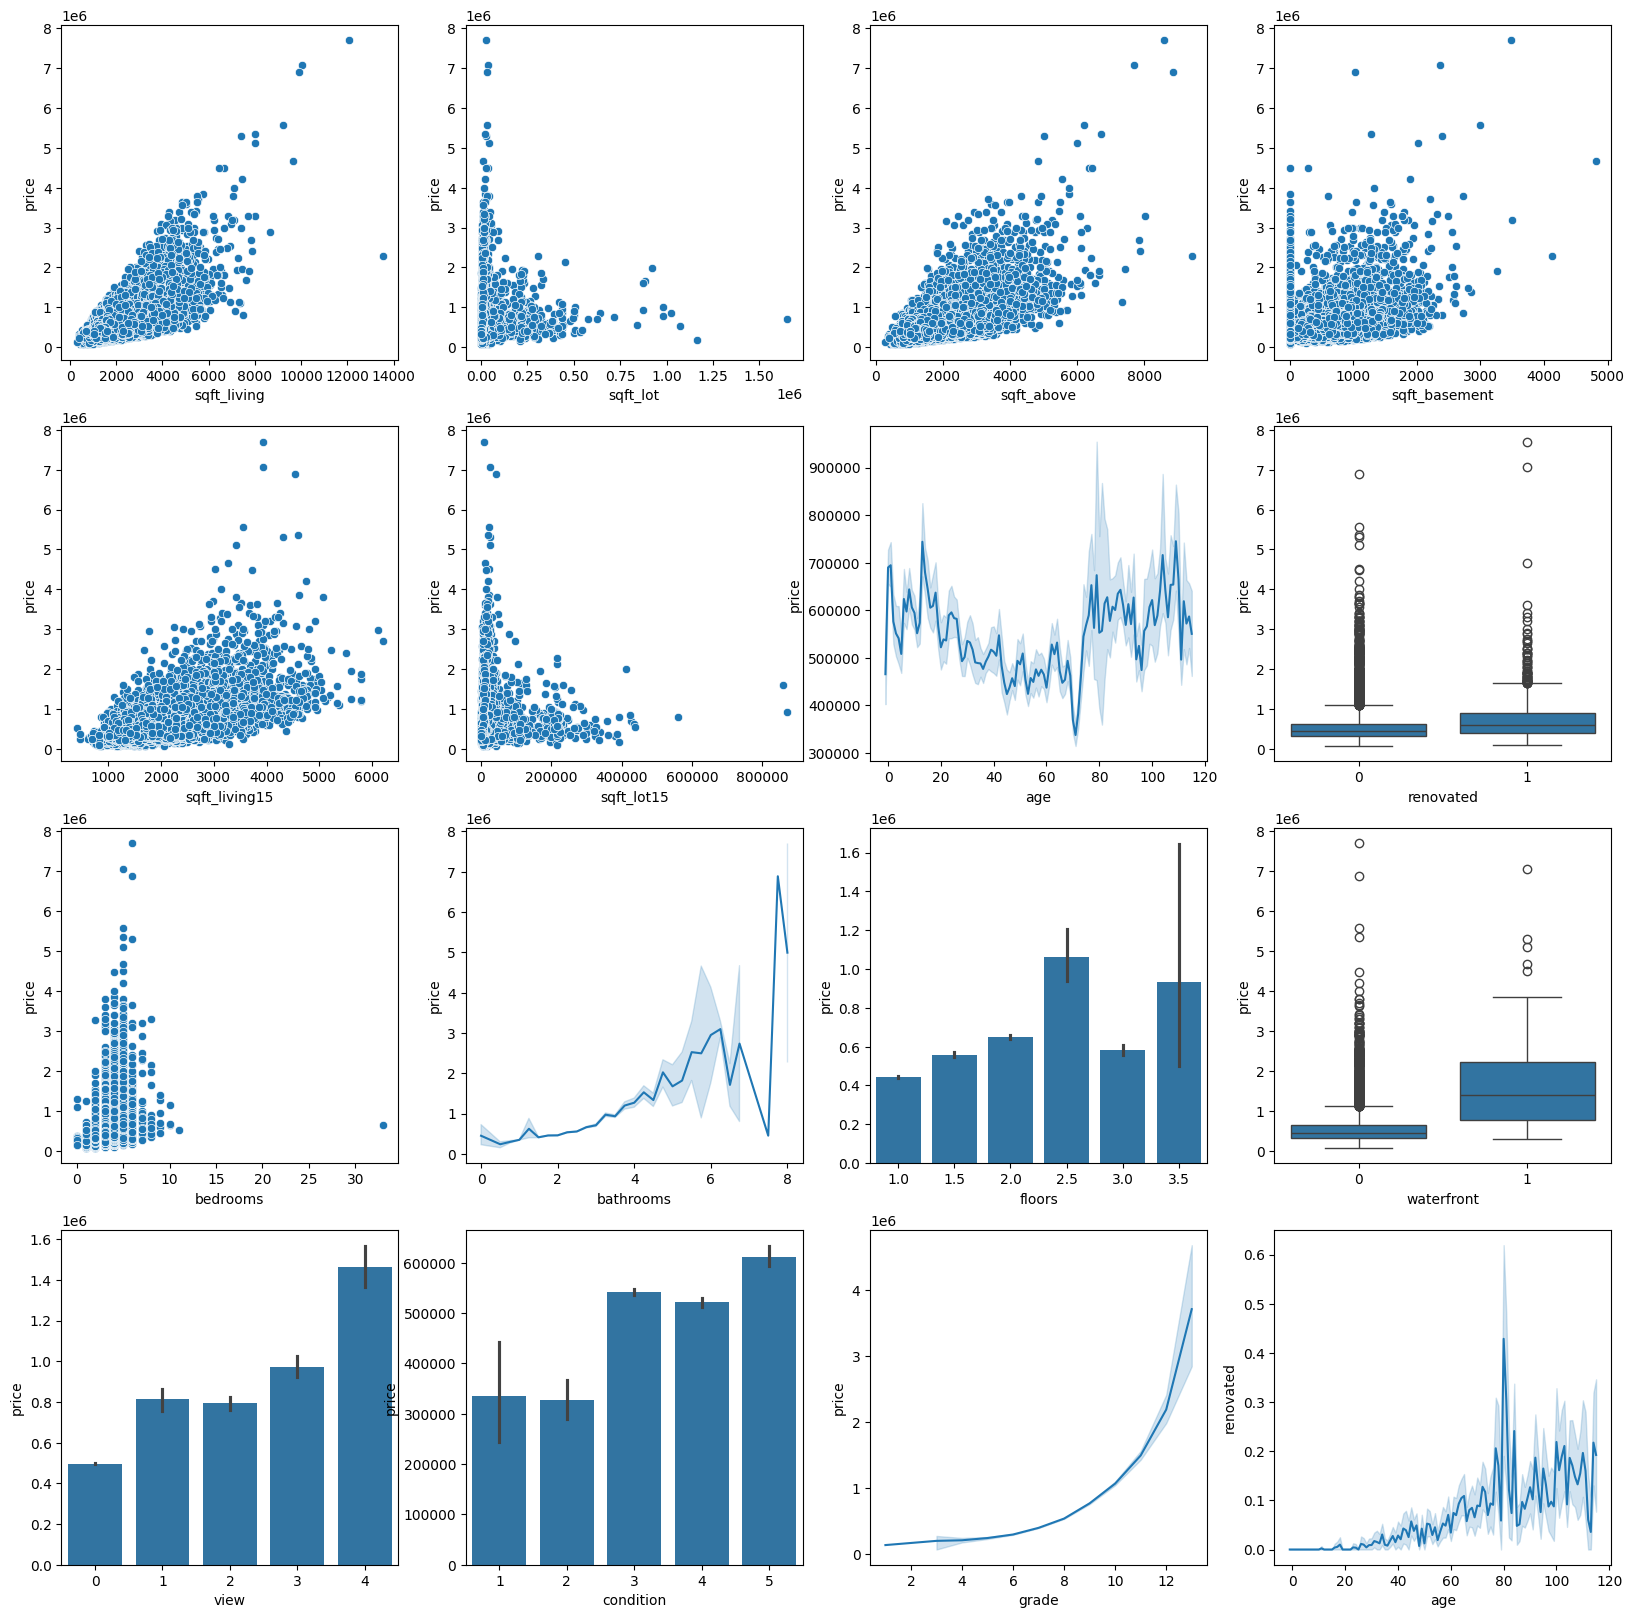

In [ ]:
# visualizing the relation between price and sqft_living, sqft_lot, sqft_above, sqft_basement, sqft_living15, sqft_lot15, age, renovated, bedrooms, bathrooms, floors, waterfront, view, condition, grade
fig, ax = plt.subplots(4,4,figsize=(20,20))
sns.scatterplot( x = df['sqft_living'], y = df['price'],ax=ax[0,0])
sns.scatterplot( x = df['sqft_lot'], y = df['price'],ax=ax[0,1])
sns.scatterplot( x = df['sqft_above'], y = df['price'],ax=ax[0,2])
sns.scatterplot( x = df['sqft_basement'], y = df['price'],ax=ax[0,3])
sns.scatterplot( x = df['sqft_living15'], y = df['price'],ax=ax[1,0])
sns.scatterplot( x = df['sqft_lot15'], y = df['price'],ax=ax[1,1])
sns.lineplot( x = df['age'], y = df['price'],ax=ax[1,2])
sns.boxplot( x = df['renovated'], y = df['price'],ax=ax[1,3])
sns.scatterplot( x = df['bedrooms'], y = df['price'],ax=ax[2,0])
sns.lineplot( x = df['bathrooms'], y = df['price'],ax=ax[2,1])
sns.barplot( x = df['floors'], y = df['price'],ax=ax[2,2])
sns.boxplot( x = df['waterfront'], y = df['price'],ax=ax[2,3])
sns.barplot( x = df['view'], y = df['price'],ax=ax[3,0])
sns.barplot( x = df['condition'], y = df['price'],ax=ax[3,1])
sns.lineplot( x = df['grade'], y = df['price'],ax=ax[3,2])
sns.lineplot( x = df['age'], y = df['renovated'],ax=ax[3,3])
plt.show()

# Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(17290, 29)
(4323, 29)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical_features = ['zipcode']

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Models
1. Linear Regression
2. Ridge Regression
3. Lasso Regularization
4. Decesion Tree Regressor
5. Random Forest Regressor

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression")
print("R²:", r2_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Linear Regression
R²: 0.7098528426101932
MAE: 125032.99729477477
RMSE: 209436.1311574074


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 200, 500]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

y_pred_ridge = ridge_grid.predict(X_test)

print("Best parameters:", ridge_grid.best_params_)
print("R²:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Best parameters: {'model__alpha': 0.1}
R²: 0.8128302046750648
MAE: 97083.43583917292
RMSE: 168213.2994251594


In [ ]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=1000))
])

lasso_params = {
    'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

y_pred_lasso = lasso_grid.predict(X_test)

print("Best alpha:", lasso_grid.best_params_)
print("R²:", r2_score(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Best alpha: {'model__alpha': 0.0001}
R²: 0.8121270283395301
MAE: 97194.85219499555
RMSE: 168528.98263900136


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 204302245945198.62, tolerance: 225891452782.19412
  model = cd_fast.sparse_enet_coordinate_descent(


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)

# Parameter grid
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit
grid_search_dt.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search_dt.best_params_)

# Best CV score
print("Best CV R²:")
print(grid_search_dt.best_score_)

# Best model
best_dt = grid_search_dt.best_estimator_

# Test prediction
y_pred_dt = best_dt.predict(X_test)

# Evaluation
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Test R²:", r2_dt)
print("Test MAE:", mae_dt)
print("Test RMSE:", rmse_dt)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Parameters:
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 20}
Best CV R²:
0.7779932939319396
Test R²: 0.7626914689270521
Test MAE: 96365.28222622172
Test RMSE: 189408.35060885578


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.7]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,          # only 20 combinations
    cv=3,               # 3-fold instead of 5-fold
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2', 0.7],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2', verbose=1)

In [ ]:
print("Best Parameters:")
print(rf_random.best_params_)

print("Best CV R²:")
print(rf_random.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20}
Best CV R²:
0.8719323820415532


In [ ]:
best_rf = rf_random.best_estimator_

y_pred_rf = best_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Test R²:", r2_rf)
print("Test MAE:", mae_rf)
print("Test RMSE:", rmse_rf)

Test R²: 0.8487671572406874
Test MAE: 73183.3844345085
Test RMSE: 151204.77440246375


/tmp/ipykernel_4595/1903867454.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=y_test,ax=ax[0,0],color='r',hist=False,label='Actual').set_title("Decision tree regressor")
/tmp/ipykernel_4595/1903867454.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=y_pred_dt,color=

<Axes: title={'center': 'Ridge'}, ylabel='Density'>

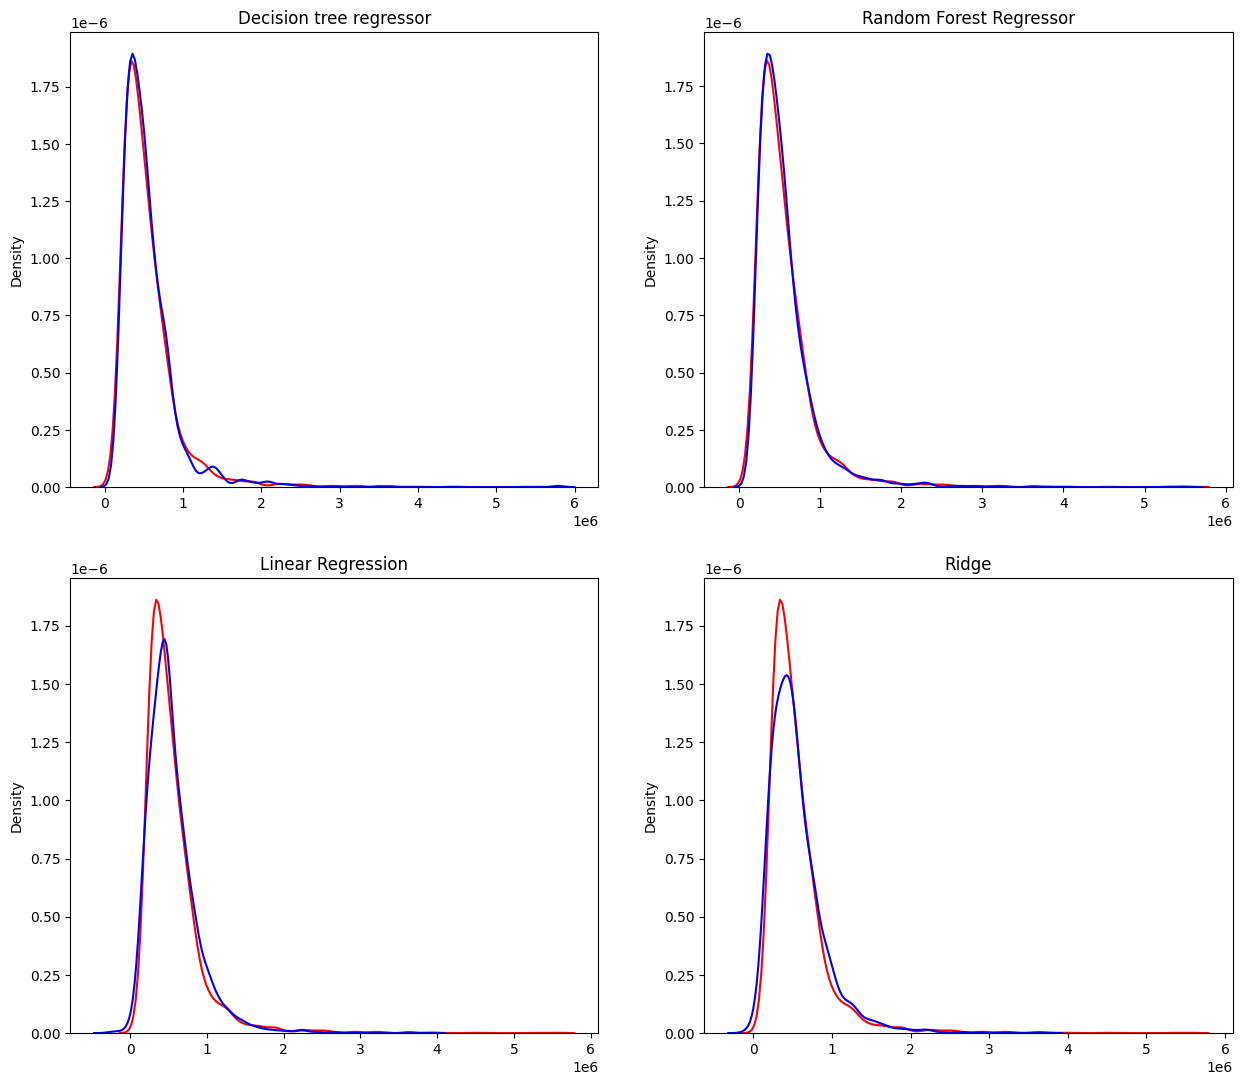

In [ ]:
# displot of the actual price and predicted price for all models

fig,ax=plt.subplots(2,2,figsize=(15,13))

#Decision Tree Regressor
sns.distplot(x=y_test,ax=ax[0,0],color='r',hist=False,label='Actual').set_title("Decision tree regressor")
sns.distplot(x=y_pred_dt,color='b',ax=ax[0,0],hist=False,label='Predicted')

#Random Forest Regressor
sns.distplot(x=y_test,ax=ax[0,1],label='Actual',color='r',hist=False).set_title("Random Forest Regressor")
sns.distplot(x=y_pred_rf,ax=ax[0,1],label='Predicted',hist=False,color='b')

#Linear Regression
sns.distplot(x=y_test,ax=ax[1,0],label='Actual',color='r',hist=False).set_title("Linear Regression")
sns.distplot(x=y_pred_lr,ax=ax[1,0],label='Predicted',hist=False,color='b')

#Ridge
sns.distplot(x=y_test,ax=ax[1,1],label='Actual',color='r',hist=False).set_title("Ridge")
sns.distplot(x=y_pred_ridge,ax=ax[1,1],label='Predicted',hist=False,color='b')



/tmp/ipykernel_4595/1172361639.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=y_test,label='Actual',color='r',hist=False).set_title("Lasso")
/tmp/ipykernel_4595/1172361639.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=y_pred_lasso,label='Predicted',hist=False,col

<Axes: title={'center': 'Lasso'}, ylabel='Density'>

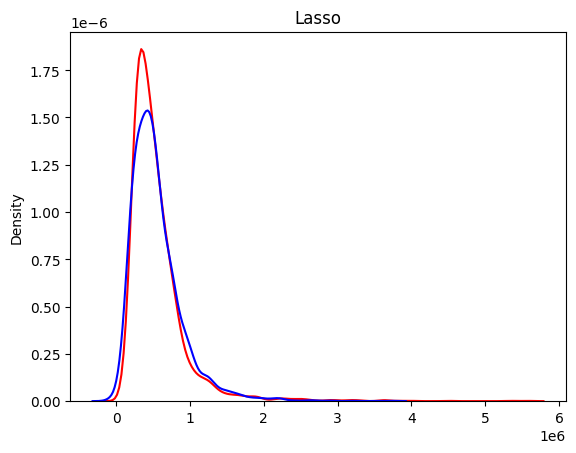

In [ ]:
#Lasso
sns.distplot(x=y_test,label='Actual',color='r',hist=False).set_title("Lasso")
sns.distplot(x=y_pred_lasso,label='Predicted',hist=False,color='b')

## Comparing all the regression metrics of each models

/tmp/ipykernel_4595/3797905166.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Linear Regression','Ridge Regression','Lasso','Random Forest','Decesion Tree'],y=[mean_absolute_error(y_test,y_pred_lr),mean_absolute_error(y_test,y_pred_ridge),mean_absolute_error(y_test,y_pred_lasso),mean_absolute_error(y_test,y_pred_rf),mean_absolute_error(y_test,y_pred_dt)],ax=ax[0],palette="Set1")
/tmp/ipykernel_4595/3797905166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Linear Regression','Ridge Regression','Lasso','Random Forest','Decesion Tree'],y=[mean_squared_error(y_test,y_pred_lr),mean_squared_error(y_test,y_pred_ridge),mean_squared_error(y_test,y_pred_lasso),mean_squared_error(y_

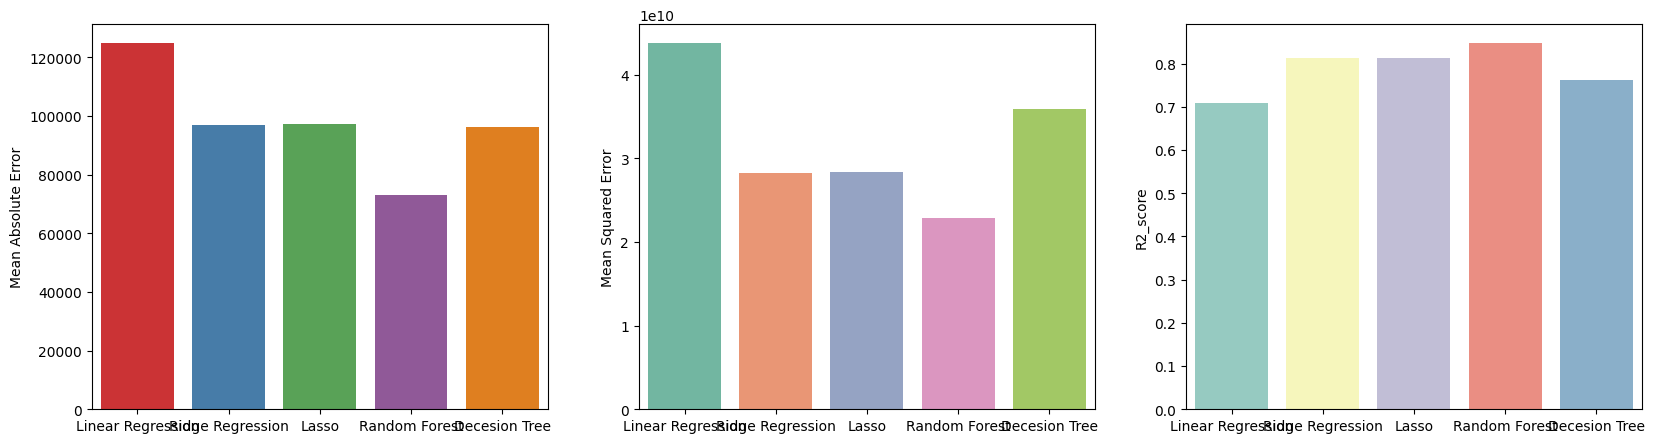

In [ ]:
#plot the graph to compare mae, mse, rmse for all models
fig, ax = plt.subplots(1,3,figsize=(20,5))
sns.barplot(x=['Linear Regression','Ridge Regression','Lasso','Random Forest','Decesion Tree'],y=[mean_absolute_error(y_test,y_pred_lr),mean_absolute_error(y_test,y_pred_ridge),mean_absolute_error(y_test,y_pred_lasso),mean_absolute_error(y_test,y_pred_rf),mean_absolute_error(y_test,y_pred_dt)],ax=ax[0],palette="Set1")
sns.barplot(x=['Linear Regression','Ridge Regression','Lasso','Random Forest','Decesion Tree'],y=[mean_squared_error(y_test,y_pred_lr),mean_squared_error(y_test,y_pred_ridge),mean_squared_error(y_test,y_pred_lasso),mean_squared_error(y_test,y_pred_rf),mean_squared_error(y_test,y_pred_dt)],ax=ax[1],palette="Set2")
sns.barplot(x=['Linear Regression','Ridge Regression','Lasso','Random Forest','Decesion Tree'],y=[r2_score(y_test,y_pred_lr),r2_score(y_test,y_pred_ridge),r2_score(y_test,y_pred_lasso),r2_score(y_test,y_pred_rf),r2_score(y_test,y_pred_dt)],ax=ax[2],palette="Set3")
# label for the graph
ax[0].set_ylabel('Mean Absolute Error')
ax[1].set_ylabel('Mean Squared Error')
ax[2].set_ylabel('R2_score')
plt.show()

In [ ]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2_lr = adjusted_r2(r2_score(y_test, y_pred_lr), n, p)
adj_r2_ridge = adjusted_r2(r2_score(y_test, y_pred_ridge), n, p)
adj_r2_lasso = adjusted_r2(r2_score(y_test, y_pred_lasso), n, p)
adj_r2_rf = adjusted_r2(r2_score(y_test, y_pred_rf), n, p)
adj_r2_dt = adjusted_r2(r2_score(y_test, y_pred_dt), n, p)

print("Adjusted R² - Linear Regression:", adj_r2_lr)
print("Adjusted R² - Ridge:", adj_r2_ridge)
print("Adjusted R² - Lasso:", adj_r2_lasso)
print("Adjusted R² - Random Forest:", adj_r2_rf)
print("Adjusted R² - Decision Tree:", adj_r2_dt)

Adjusted R² - Linear Regression: 0.7078928455069311
Adjusted R² - Ridge: 0.81156583848256
Adjusted R² - Lasso: 0.8108579120622988
Adjusted R² - Random Forest: 0.847745551734044
Adjusted R² - Decision Tree: 0.7610884064064103
